# Notebook 6 - Train, Tune, and Final Evaluation

## Purpose

Complete the model-development stage using the fitted feature-engineering
artifacts from Notebook 5.

This notebook has four jobs:

1. establish a simple baseline;
2. train candidate model configurations;
3. select hyperparameters and a decision threshold using validation data;
4. evaluate the frozen model once on the chronological test split.

## Critical preprocessing rule

Notebook 5 already fitted the preprocessing object on training data.

This notebook **loads that fitted object and reuses it**.

- Training preprocessing is not fitted again.
- Validation preprocessing uses `.transform(...)` only.
- Test preprocessing uses `.transform(...)` only.
- Test data is not opened until model and threshold selection are frozen.

## Primary metric

Average Precision / PR-AUC is the primary model-selection metric because
late deliveries are the minority class.

ROC-AUC, precision, recall, and F1 are reported as supporting metrics.

## Output artifacts

- `artifacts/notebook6_trained_model.joblib`
- `artifacts/notebook6_results.json`

## 1. Imports and project paths

In [1]:
from hashlib import sha256
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

RANDOM_STATE = 42

print(f"pandas version: {pd.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print("Imports completed successfully.")

pandas version: 3.0.5
scikit-learn version: 1.9.0
Imports completed successfully.


In [2]:
WORKING_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    WORKING_DIR.parent
    if WORKING_DIR.name == "notebooks"
    else WORKING_DIR
)

assert (
    PROJECT_ROOT / "docker-compose.yml"
).exists(), "Project root could not be identified."

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"

NB5_TRAIN_FEATURES_PATH = (
    ARTIFACT_DIR
    / "notebook5_train_features.parquet"
)

NB5_PREPROCESSOR_PATH = (
    ARTIFACT_DIR
    / "notebook5_preprocessor.joblib"
)

NB5_FEATURE_LIST_PATH = (
    ARTIFACT_DIR
    / "notebook5_feature_list.json"
)

NB5_MANIFEST_PATH = (
    ARTIFACT_DIR
    / "notebook5_manifest.json"
)

VALIDATION_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "validation.parquet"
)

# Test path is defined now, but the test file is deliberately
# NOT opened until the final-evaluation section.
TEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "test.parquet"
)

MODEL_PATH = (
    ARTIFACT_DIR
    / "notebook6_trained_model.joblib"
)

RESULTS_PATH = (
    ARTIFACT_DIR
    / "notebook6_results.json"
)

print(f"Project root: {PROJECT_ROOT}")
print("Notebook 6 paths resolved.")
print("Test data opened: NO")

Project root: D:\Documents\mlops-olist
Notebook 6 paths resolved.
Test data opened: NO


## 2. Verify Notebook 5 artifacts

Notebook 6 refuses to proceed if the Notebook 5 artifact hashes do not
match its manifest.

This prevents silently using a different feature table, feature order,
or fitted transformer.


In [3]:
def file_sha256(path):
    return (
        sha256(path.read_bytes())
        .hexdigest()
        .upper()
    )


required_nb5_artifacts = [
    NB5_TRAIN_FEATURES_PATH,
    NB5_PREPROCESSOR_PATH,
    NB5_FEATURE_LIST_PATH,
    NB5_MANIFEST_PATH,
]

for artifact_path in required_nb5_artifacts:
    assert artifact_path.exists(), (
        f"Missing Notebook 5 artifact: "
        f"{artifact_path}"
    )

nb5_manifest = json.loads(
    NB5_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

assert (
    nb5_manifest["producer"]
    == "notebooks/05_feature_engineering.ipynb"
)

assert (
    nb5_manifest["fitted_on_split"]
    == "train"
)

assert (
    nb5_manifest["validation_opened"]
    is False
)

assert (
    nb5_manifest["test_opened"]
    is False
)

assert (
    nb5_manifest["model_trained"]
    is False
)

artifact_checks = {
    "train_feature_table": (
        NB5_TRAIN_FEATURES_PATH
    ),
    "fitted_preprocessor": (
        NB5_PREPROCESSOR_PATH
    ),
    "feature_list": (
        NB5_FEATURE_LIST_PATH
    ),
}

for artifact_name, artifact_path in artifact_checks.items():
    expected_hash = (
        nb5_manifest["artifacts"]
        [artifact_name]["sha256"]
    )

    actual_hash = file_sha256(
        artifact_path
    )

    assert actual_hash == expected_hash, (
        f"SHA-256 mismatch for "
        f"{artifact_name}"
    )

    print(
        f"{artifact_name} SHA-256: PASSED"
    )

print("Notebook 5 artifact contract: PASSED")
print("Test data opened: NO")

train_feature_table SHA-256: PASSED
fitted_preprocessor SHA-256: PASSED
feature_list SHA-256: PASSED
Notebook 5 artifact contract: PASSED
Test data opened: NO


## 3. Load the fitted preprocessor and final training feature table

The transformed training table was produced by Notebook 5 using
`fit_transform(...)` on training data only.

Notebook 6 does **not** fit the preprocessor again.


In [4]:
preprocessor = joblib.load(
    NB5_PREPROCESSOR_PATH
)

feature_names = json.loads(
    NB5_FEATURE_LIST_PATH.read_text(
        encoding="utf-8"
    )
)

train_features = pd.read_parquet(
    NB5_TRAIN_FEATURES_PATH
)

assert (
    preprocessor
    .get_feature_names_out()
    .tolist()
    == feature_names
)

assert (
    len(feature_names)
    == nb5_manifest[
        "final_feature_count"
    ]
)

assert (
    train_features.shape
    == (
        nb5_manifest["training_rows"],
        len(feature_names) + 1,
    )
)

X_train = train_features[
    feature_names
].copy()

y_train = (
    train_features["is_late"]
    .astype(int)
)

print(
    f"Training rows: "
    f"{len(X_train):,}"
)

print(
    f"Ordered model features: "
    f"{len(feature_names)}"
)

print(
    "Preprocessor loaded from Notebook 5: YES"
)

print(
    "Preprocessor fitted again: NO"
)

print(
    "Test data opened: NO"
)

Training rows: 67,529
Ordered model features: 184
Preprocessor loaded from Notebook 5: YES
Preprocessor fitted again: NO
Test data opened: NO


## 4. Reproduce Notebook 5 deterministic feature engineering

The deterministic calculations below do not learn parameters.

They reproduce the raw-to-engineered feature step from Notebook 5 before
the saved fitted preprocessor is applied.

The learned operations?imputation, scaling, rare-category handling, and
one-hot encoding?remain frozen inside the saved Notebook 5 preprocessor.


In [5]:
BASE_NUMERIC_FEATURES = [
    "item_count",
    "unique_product_count",
    "unique_seller_count",
    "item_price_total",
    "item_price_mean",
    "item_price_max",
    "freight_value_total",
    "freight_value_mean",
    "unique_product_category_count",
    "product_name_length_mean",
    "product_description_length_mean",
    "product_photos_qty_mean",
    "product_weight_g_total",
    "product_weight_g_mean",
    "product_length_cm_mean",
    "product_height_cm_mean",
    "product_width_cm_mean",
    "primary_category_item_count",
    "unique_seller_city_count",
    "unique_seller_state_count",
    "primary_seller_item_count",
    "payment_record_count",
    "unique_payment_type_count",
    "payment_value_total",
    "payment_value_mean",
    "payment_installments_max",
    "payment_installments_mean",
    "primary_payment_type_value",
    "primary_payment_type_record_count",
    "customer_lat_median",
    "customer_lng_median",
    "customer_geolocation_record_count",
    "primary_seller_lat_median",
    "primary_seller_lng_median",
    "primary_seller_geolocation_record_count",
]

BASE_CATEGORICAL_FEATURES = [
    "customer_record_found",
    "customer_state",
    "primary_seller_state",
    "primary_product_category",
    "primary_payment_type",
]


def haversine_km(
    lat1,
    lon1,
    lat2,
    lon2,
):
    lat1 = np.radians(
        pd.to_numeric(
            lat1,
            errors="coerce",
        )
    )

    lon1 = np.radians(
        pd.to_numeric(
            lon1,
            errors="coerce",
        )
    )

    lat2 = np.radians(
        pd.to_numeric(
            lat2,
            errors="coerce",
        )
    )

    lon2 = np.radians(
        pd.to_numeric(
            lon2,
            errors="coerce",
        )
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return (
        6371.0088
        * 2
        * np.arcsin(
            np.sqrt(a)
        )
    )


def build_prediction_features(frame):
    X = frame[
        BASE_NUMERIC_FEATURES
        + BASE_CATEGORICAL_FEATURES
    ].copy()

    for column in BASE_NUMERIC_FEATURES:
        X[column] = pd.to_numeric(
            X[column],
            errors="coerce",
        )

    for column in BASE_CATEGORICAL_FEATURES:
        X[column] = X[column].astype(
            "object"
        )

        X.loc[
            X[column].isna(),
            column,
        ] = np.nan

    purchase = pd.to_datetime(
        frame[
            "order_purchase_timestamp"
        ],
        errors="coerce",
    )

    approved = pd.to_datetime(
        frame["order_approved_at"],
        errors="coerce",
    )

    estimated = pd.to_datetime(
        frame[
            "order_estimated_delivery_date"
        ],
        errors="coerce",
    )

    shipping_min = pd.to_datetime(
        frame["shipping_limit_date_min"],
        errors="coerce",
    )

    shipping_max = pd.to_datetime(
        frame["shipping_limit_date_max"],
        errors="coerce",
    )

    X["approval_delay_hours"] = (
        approved - purchase
    ).dt.total_seconds() / 3600

    X[
        "estimated_delivery_window_days"
    ] = (
        estimated - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_min_days"] = (
        shipping_min - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_max_days"] = (
        shipping_max - purchase
    ).dt.total_seconds() / 86400

    X["shipping_limit_span_days"] = (
        shipping_max - shipping_min
    ).dt.total_seconds() / 86400

    X["purchase_month"] = (
        purchase.dt.month.astype(
            "float64"
        )
    )

    X["purchase_day_of_week"] = (
        purchase.dt.dayofweek.astype(
            "float64"
        )
    )

    X["purchase_hour"] = (
        purchase.dt.hour.astype(
            "float64"
        )
    )

    X[
        "customer_seller_distance_km"
    ] = haversine_km(
        frame["customer_lat_median"],
        frame["customer_lng_median"],
        frame[
            "primary_seller_lat_median"
        ],
        frame[
            "primary_seller_lng_median"
        ],
    )

    X["freight_to_price_ratio"] = (
        pd.to_numeric(
            frame["freight_value_total"],
            errors="coerce",
        )
        /
        pd.to_numeric(
            frame["item_price_total"],
            errors="coerce",
        ).replace(
            0,
            np.nan,
        )
    )

    same_state = (
        frame["customer_state"]
        .eq(
            frame[
                "primary_seller_state"
            ]
        )
    )

    missing_state = (
        frame[
            [
                "customer_state",
                "primary_seller_state",
            ]
        ]
        .isna()
        .any(axis=1)
    )

    X[
        "customer_seller_same_state"
    ] = (
        same_state
        .mask(
            missing_state,
            np.nan,
        )
        .astype(float)
    )

    return X


print(
    "Deterministic feature function defined."
)

print(
    "Learned preprocessing fitted here: NO"
)

print(
    "Test data opened: NO"
)

Deterministic feature function defined.
Learned preprocessing fitted here: NO
Test data opened: NO


## 5. Open validation data and transform with the frozen preprocessor

Validation is now used for model and threshold selection.

The preprocessor is reused with `.transform(...)` only.


In [6]:
assert VALIDATION_PATH.exists(), (
    f"Missing validation artifact: "
    f"{VALIDATION_PATH}"
)

validation = pd.read_parquet(
    VALIDATION_PATH
)

assert (
    validation.shape
    == (14_470, 67)
)

X_validation_raw = (
    build_prediction_features(
        validation
    )
)

X_validation_array = (
    preprocessor.transform(
        X_validation_raw
    )
)

X_validation = pd.DataFrame(
    X_validation_array,
    columns=feature_names,
    index=validation.index,
).astype("float32")

y_validation = (
    validation["is_late"]
    .astype(int)
)

assert (
    list(X_validation.columns)
    == feature_names
)

assert (
    X_validation.shape[1]
    == X_train.shape[1]
)

print(
    f"Validation rows: "
    f"{len(validation):,}"
)

print(
    f"Validation late rate: "
    f"{y_validation.mean():.4%}"
)

print(
    "Validation preprocessing method: transform ONLY"
)

print(
    "Preprocessor refitted: NO"
)

print(
    "Test data opened: NO"
)

Validation rows: 14,470


Validation late rate: 4.3124%
Validation preprocessing method: transform ONLY
Preprocessor refitted: NO
Test data opened: NO


## 6. Establish a simple baseline

A dummy classifier provides a no-skill reference before any real model is
selected.

For an imbalanced binary problem, the no-skill PR-AUC is approximately
the positive-class prevalence.


In [7]:
baseline_model = DummyClassifier(
    strategy="prior"
)

baseline_model.fit(
    X_train,
    y_train,
)

baseline_probability = (
    baseline_model.predict_proba(
        X_validation
    )[:, 1]
)

baseline_prediction = (
    baseline_model.predict(
        X_validation
    )
)

baseline_metrics = {
    "accuracy": float(
        accuracy_score(
            y_validation,
            baseline_prediction,
        )
    ),
    "precision": float(
        precision_score(
            y_validation,
            baseline_prediction,
            zero_division=0,
        )
    ),
    "recall": float(
        recall_score(
            y_validation,
            baseline_prediction,
            zero_division=0,
        )
    ),
    "f1": float(
        f1_score(
            y_validation,
            baseline_prediction,
            zero_division=0,
        )
    ),
    "average_precision": float(
        average_precision_score(
            y_validation,
            baseline_probability,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_validation,
            baseline_probability,
        )
    ),
}

print("BASELINE VALIDATION RESULT")

for metric_name, metric_value in baseline_metrics.items():
    print(
        f"{metric_name}: "
        f"{metric_value:.6f}"
    )

print(
    "Baseline established before model tuning: YES"
)

print(
    "Test data opened: NO"
)

BASELINE VALIDATION RESULT


accuracy: 0.956876
precision: 0.000000
recall: 0.000000
f1: 0.000000
average_precision: 0.043124
roc_auc: 0.500000
Baseline established before model tuning: YES
Test data opened: NO


## 7. Tune balanced logistic regression on validation data

The model family is balanced logistic regression.

A small, explicit hyperparameter grid is evaluated using validation
PR-AUC as the primary selection metric.

Only the training split is used to fit candidate models.
Validation is used to compare the candidates.


In [8]:
CANDIDATE_C_VALUES = [
    0.1,
    1.0,
    10.0,
]

candidate_models = {}
candidate_records = []

for c_value in CANDIDATE_C_VALUES:
    model_name = (
        f"logistic_balanced_C_{c_value}"
    )

    model = LogisticRegression(
        C=c_value,
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    probability = (
        model.predict_proba(
            X_validation
        )[:, 1]
    )

    prediction = (
        probability >= 0.5
    ).astype(int)

    record = {
        "model": model_name,
        "C": float(c_value),
        "accuracy": float(
            accuracy_score(
                y_validation,
                prediction,
            )
        ),
        "precision": float(
            precision_score(
                y_validation,
                prediction,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_validation,
                prediction,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_validation,
                prediction,
                zero_division=0,
            )
        ),
        "roc_auc": float(
            roc_auc_score(
                y_validation,
                probability,
            )
        ),
        "average_precision": float(
            average_precision_score(
                y_validation,
                probability,
            )
        ),
    }

    candidate_records.append(
        record
    )

    candidate_models[
        model_name
    ] = model

candidate_results = (
    pd.DataFrame(
        candidate_records
    )
    .sort_values(
        [
            "average_precision",
            "roc_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    candidate_results.style.format(
        {
            "C": "{:.4f}",
            "accuracy": "{:.4f}",
            "precision": "{:.4f}",
            "recall": "{:.4f}",
            "f1": "{:.4f}",
            "roc_auc": "{:.4f}",
            "average_precision": "{:.4f}",
        }
    )
)

best_model_name = (
    candidate_results.iloc[0][
        "model"
    ]
)

selected_c = float(
    candidate_results.iloc[0]["C"]
)

selected_model = (
    candidate_models[
        best_model_name
    ]
)

print(
    f"Selected model: "
    f"{best_model_name}"
)

print(
    f"Selected C: "
    f"{selected_c}"
)

print(
    "Selection metric: validation PR-AUC"
)

print(
    "Test data opened: NO"
)

,model,C,accuracy,precision,recall,f1,roc_auc,average_precision
0,logistic_balanced_C_0.1,0.1000,0.7051,0.0971,0.7035,0.1707,0.7756,0.1341
1,logistic_balanced_C_1.0,1.0000,0.7058,0.0977,0.7067,0.1716,0.7737,0.1328
2,logistic_balanced_C_10.0,10.0000,0.7062,0.0980,0.7083,0.1721,0.7737,0.1326


Selected model: logistic_balanced_C_0.1
Selected C: 0.1
Selection metric: validation PR-AUC
Test data opened: NO


## 8. Select and freeze the classification threshold

The selected model's validation probabilities are used to choose a
decision threshold.

The threshold maximizing validation F1 is frozen **before** opening the
test set.


In [9]:
validation_probability = (
    selected_model.predict_proba(
        X_validation
    )[:, 1]
)

precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probability,
    )
)

numerator = (
    2
    * precision_values[:-1]
    * recall_values[:-1]
)

denominator = (
    precision_values[:-1]
    + recall_values[:-1]
)

f1_values = np.divide(
    numerator,
    denominator,
    out=np.zeros_like(
        numerator
    ),
    where=(
        denominator != 0
    ),
)

best_threshold_index = int(
    np.nanargmax(
        f1_values
    )
)

SELECTED_THRESHOLD = float(
    thresholds[
        best_threshold_index
    ]
)

validation_threshold_prediction = (
    validation_probability
    >= SELECTED_THRESHOLD
).astype(int)

selected_validation_metrics = {
    "precision": float(
        precision_score(
            y_validation,
            validation_threshold_prediction,
            zero_division=0,
        )
    ),
    "recall": float(
        recall_score(
            y_validation,
            validation_threshold_prediction,
            zero_division=0,
        )
    ),
    "f1": float(
        f1_score(
            y_validation,
            validation_threshold_prediction,
            zero_division=0,
        )
    ),
    "average_precision": float(
        average_precision_score(
            y_validation,
            validation_probability,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_validation,
            validation_probability,
        )
    ),
}

print("FROZEN MODEL SELECTION")

print(
    f"Model: "
    f"{best_model_name}"
)

print(
    f"C: "
    f"{selected_c}"
)

print(
    f"Threshold: "
    f"{SELECTED_THRESHOLD:.6f}"
)

for metric_name, metric_value in (
    selected_validation_metrics.items()
):
    print(
        f"validation_{metric_name}: "
        f"{metric_value:.6f}"
    )

print(
    "Model frozen before test: YES"
)

print(
    "Threshold frozen before test: YES"
)

print(
    "Test data opened: NO"
)

FROZEN MODEL SELECTION
Model: logistic_balanced_C_0.1
C: 0.1
Threshold: 0.692968
validation_precision: 0.165799
validation_recall: 0.357372
validation_f1: 0.226511
validation_average_precision: 0.134065
validation_roc_auc: 0.775557
Model frozen before test: YES
Threshold frozen before test: YES
Test data opened: NO


## 9. Save the frozen trained model before test evaluation

The selected model is serialized **before** the test set is opened.

This provides evidence that no model parameters are changed in response
to final test performance.

The fitted Notebook 5 preprocessor remains a separate required artifact.


In [10]:
joblib.dump(
    selected_model,
    MODEL_PATH,
)

MODEL_SHA256_BEFORE_TEST = (
    file_sha256(
        MODEL_PATH
    )
)

PREPROCESSOR_SHA256 = (
    file_sha256(
        NB5_PREPROCESSOR_PATH
    )
)

FEATURE_LIST_SHA256 = (
    file_sha256(
        NB5_FEATURE_LIST_PATH
    )
)

print(
    f"Frozen model artifact: "
    f"{MODEL_PATH}"
)

print(
    f"Frozen model SHA-256: "
    f"{MODEL_SHA256_BEFORE_TEST}"
)

print(
    f"Frozen preprocessor SHA-256: "
    f"{PREPROCESSOR_SHA256}"
)

print(
    "Model saved before test open: YES"
)

print(
    "Test data opened: NO"
)

Frozen model artifact: D:\Documents\mlops-olist\artifacts\notebook6_trained_model.joblib
Frozen model SHA-256: 91238DCC01631547D47012F0F7FD2B04656679A69EBF7E16E474692CB8E3301F
Frozen preprocessor SHA-256: 33B34D3781BA235DD5C2B1570F156E4A8C4F04FE78DE56B629E59A017010DA31
Model saved before test open: YES
Test data opened: NO


## 10. Final one-time test evaluation

The model configuration, fitted coefficients, preprocessing object,
feature order, and threshold are now frozen.

Only now is the chronological test split opened.

The test results are reported, not used for further tuning.


In [11]:
assert TEST_PATH.exists(), (
    f"Missing test artifact: "
    f"{TEST_PATH}"
)

print("=== FINAL TEST OPEN ===")

test = pd.read_parquet(
    TEST_PATH
)

assert (
    test.shape
    == (14_471, 67)
)

X_test_raw = (
    build_prediction_features(
        test
    )
)

# CRITICAL:
# Reuse the preprocessor fitted in Notebook 5.
# No fit or fit_transform occurs here.
X_test_array = (
    preprocessor.transform(
        X_test_raw
    )
)

X_test = pd.DataFrame(
    X_test_array,
    columns=feature_names,
    index=test.index,
).astype("float32")

y_test = (
    test["is_late"]
    .astype(int)
)

assert (
    list(X_test.columns)
    == feature_names
)

assert (
    X_test.shape[1]
    == X_train.shape[1]
)

test_probability = (
    selected_model.predict_proba(
        X_test
    )[:, 1]
)

test_prediction = (
    test_probability
    >= SELECTED_THRESHOLD
).astype(int)

test_metrics = {
    "accuracy": float(
        accuracy_score(
            y_test,
            test_prediction,
        )
    ),
    "precision": float(
        precision_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "recall": float(
        recall_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "f1": float(
        f1_score(
            y_test,
            test_prediction,
            zero_division=0,
        )
    ),
    "average_precision": float(
        average_precision_score(
            y_test,
            test_probability,
        )
    ),
    "roc_auc": float(
        roc_auc_score(
            y_test,
            test_probability,
        )
    ),
}

test_no_skill_pr_auc = float(
    y_test.mean()
)

test_pr_auc_lift = float(
    test_metrics[
        "average_precision"
    ]
    / test_no_skill_pr_auc
)

test_cm = confusion_matrix(
    y_test,
    test_prediction,
)

tn, fp, fn, tp = (
    test_cm.ravel()
)

print(
    f"Test rows: "
    f"{len(test):,}"
)

print(
    f"Test late orders: "
    f"{int(y_test.sum()):,}"
)

print(
    f"Test late rate: "
    f"{y_test.mean():.4%}"
)

for metric_name, metric_value in (
    test_metrics.items()
):
    print(
        f"test_{metric_name}: "
        f"{metric_value:.6f}"
    )

print(
    f"test_no_skill_pr_auc: "
    f"{test_no_skill_pr_auc:.6f}"
)

print(
    f"test_pr_auc_lift: "
    f"{test_pr_auc_lift:.2f}x"
)

print(
    f"true_positives: {tp:,}"
)

print(
    f"false_negatives: {fn:,}"
)

print(
    f"false_positives: {fp:,}"
)

print(
    f"true_negatives: {tn:,}"
)

print(
    "Test preprocessing method: transform ONLY"
)

print(
    "Preprocessor refitted on test: NO"
)

print(
    "Model tuned on test: NO"
)

=== FINAL TEST OPEN ===
Test rows: 14,471
Test late orders: 620
Test late rate: 4.2844%
test_accuracy: 0.814042
test_precision: 0.071931
test_recall: 0.280645
test_f1: 0.114511
test_average_precision: 0.081893
test_roc_auc: 0.657710
test_no_skill_pr_auc: 0.042844
test_pr_auc_lift: 1.91x
true_positives: 174
false_negatives: 446
false_positives: 2,245
true_negatives: 11,606
Test preprocessing method: transform ONLY
Preprocessor refitted on test: NO
Model tuned on test: NO


## 11. Final confusion matrix

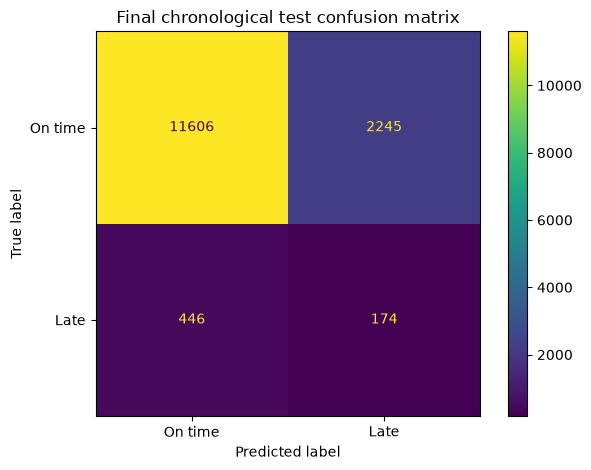

In [12]:
ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=[
        "On time",
        "Late",
    ],
).plot()

plt.title(
    "Final chronological test "
    "confusion matrix"
)

plt.tight_layout()
plt.show()

## 12. Confirm the frozen model was not changed after test

The trained-model file hash is compared with the hash captured before
test data was opened.


In [13]:
MODEL_SHA256_AFTER_TEST = (
    file_sha256(
        MODEL_PATH
    )
)

assert (
    MODEL_SHA256_AFTER_TEST
    == MODEL_SHA256_BEFORE_TEST
)

print(
    f"Model SHA-256 before test: "
    f"{MODEL_SHA256_BEFORE_TEST}"
)

print(
    f"Model SHA-256 after test:  "
    f"{MODEL_SHA256_AFTER_TEST}"
)

print(
    "Model artifact changed after test: NO"
)

Model SHA-256 before test: 91238DCC01631547D47012F0F7FD2B04656679A69EBF7E16E474692CB8E3301F
Model SHA-256 after test:  91238DCC01631547D47012F0F7FD2B04656679A69EBF7E16E474692CB8E3301F
Model artifact changed after test: NO


## 13. Save the final results summary

The results artifact records:

- baseline performance;
- all validation hyperparameter candidates;
- selected model and hyperparameter;
- frozen threshold;
- validation performance;
- final test performance;
- confusion-matrix counts;
- fitted preprocessor and feature-list hashes;
- trained model hash.

The test metrics are documentation only. No tuning follows this section.


In [14]:
results_summary = {
    "producer": (
        "notebooks/"
        "06_train_tune_evaluate.ipynb"
    ),
    "notebook5_manifest_sha256": (
        file_sha256(
            NB5_MANIFEST_PATH
        )
    ),
    "preprocessor": {
        "path": (
            "artifacts/"
            "notebook5_preprocessor.joblib"
        ),
        "sha256": (
            PREPROCESSOR_SHA256
        ),
        "fitted_on": "train",
        "refitted_in_notebook6": False,
    },
    "feature_list": {
        "path": (
            "artifacts/"
            "notebook5_feature_list.json"
        ),
        "sha256": (
            FEATURE_LIST_SHA256
        ),
        "feature_count": int(
            len(feature_names)
        ),
    },
    "training_rows": int(
        len(X_train)
    ),
    "validation_rows": int(
        len(X_validation)
    ),
    "test_rows": int(
        len(X_test)
    ),
    "primary_selection_metric": (
        "average_precision"
    ),
    "baseline_validation": (
        baseline_metrics
    ),
    "candidate_validation_results": (
        json.loads(
            candidate_results.to_json(
                orient="records"
            )
        )
    ),
    "selected_model": {
        "family": (
            "LogisticRegression"
        ),
        "class_weight": "balanced",
        "C": float(
            selected_c
        ),
        "threshold": float(
            SELECTED_THRESHOLD
        ),
        "validation_metrics": (
            selected_validation_metrics
        ),
    },
    "trained_model": {
        "path": (
            "artifacts/"
            "notebook6_trained_model.joblib"
        ),
        "sha256": (
            MODEL_SHA256_AFTER_TEST
        ),
        "changed_after_test": False,
    },
    "test": {
        "metrics": (
            test_metrics
        ),
        "no_skill_pr_auc": (
            test_no_skill_pr_auc
        ),
        "pr_auc_lift": (
            test_pr_auc_lift
        ),
        "confusion_matrix": {
            "true_negative": int(tn),
            "false_positive": int(fp),
            "false_negative": int(fn),
            "true_positive": int(tp),
        },
    },
    "test_used_for_tuning": False,
}

RESULTS_PATH.write_text(
    json.dumps(
        results_summary,
        indent=2,
        sort_keys=True,
    ),
    encoding="utf-8",
)

reloaded_results = json.loads(
    RESULTS_PATH.read_text(
        encoding="utf-8"
    )
)

assert (
    reloaded_results
    == results_summary
)

print(
    f"Results artifact: "
    f"{RESULTS_PATH}"
)

print(
    f"Results SHA-256: "
    f"{file_sha256(RESULTS_PATH)}"
)

print(
    "Results reload validation: PASSED"
)

Results artifact: D:\Documents\mlops-olist\artifacts\notebook6_results.json
Results SHA-256: E74ED01E74EAA6B65C302DD23C158144591CBDFDE2A6C710BFE2AF88CBE2B72E
Results reload validation: PASSED


## 14. Notebook 6 completion contract

Notebook 6 is complete when:

- Notebook 5's fitted artifacts are hash-verified;
- preprocessing is never refitted;
- a no-skill baseline is established;
- model hyperparameters are compared using validation data;
- PR-AUC is the primary selection metric;
- the decision threshold is selected using validation data;
- model and threshold are frozen before test;
- the trained-model artifact is saved before test is opened;
- the chronological test split is opened only for final evaluation;
- test preprocessing uses `.transform(...)` only;
- no model tuning occurs after test;
- the model artifact hash is unchanged after test;
- a trained-model artifact is saved;
- a results-summary artifact is saved and reload-validated.


In [15]:
print("NOTEBOOK 6 FINAL RESULT")

print(
    f"Training rows: "
    f"{len(X_train):,}"
)

print(
    f"Validation rows: "
    f"{len(X_validation):,}"
)

print(
    f"Test rows: "
    f"{len(X_test):,}"
)

print(
    f"Final encoded features: "
    f"{len(feature_names)}"
)

print(
    f"Baseline validation PR-AUC: "
    f"{baseline_metrics['average_precision']:.6f}"
)

print(
    f"Selected model: "
    f"{best_model_name}"
)

print(
    f"Selected C: "
    f"{selected_c}"
)

print(
    f"Frozen threshold: "
    f"{SELECTED_THRESHOLD:.6f}"
)

print(
    f"Validation PR-AUC: "
    f"{selected_validation_metrics['average_precision']:.6f}"
)

print(
    f"Validation ROC-AUC: "
    f"{selected_validation_metrics['roc_auc']:.6f}"
)

print(
    f"Test PR-AUC: "
    f"{test_metrics['average_precision']:.6f}"
)

print(
    f"Test ROC-AUC: "
    f"{test_metrics['roc_auc']:.6f}"
)

print(
    f"Test precision: "
    f"{test_metrics['precision']:.6f}"
)

print(
    f"Test recall: "
    f"{test_metrics['recall']:.6f}"
)

print(
    f"Test F1: "
    f"{test_metrics['f1']:.6f}"
)

print(
    f"Test PR-AUC lift: "
    f"{test_pr_auc_lift:.2f}x"
)

print(
    "Notebook 5 fitted preprocessor reused: YES"
)

print(
    "Preprocessor refitted in Notebook 6: NO"
)

print(
    "Baseline completed before tuning: YES"
)

print(
    "Hyperparameters selected using validation: YES"
)

print(
    "Threshold selected using validation: YES"
)

print(
    "Model frozen before test: YES"
)

print(
    "Test used for tuning: NO"
)

print(
    "Model artifact changed after test: NO"
)

print(
    "Trained model artifact saved: YES"
)

print(
    "Results summary artifact saved: YES"
)

print(
    "Final Task 2 model evaluation complete: YES"
)

NOTEBOOK 6 FINAL RESULT
Training rows: 67,529
Validation rows: 14,470
Test rows: 14,471
Final encoded features: 184
Baseline validation PR-AUC: 0.043124
Selected model: logistic_balanced_C_0.1
Selected C: 0.1
Frozen threshold: 0.692968
Validation PR-AUC: 0.134065
Validation ROC-AUC: 0.775557
Test PR-AUC: 0.081893
Test ROC-AUC: 0.657710
Test precision: 0.071931
Test recall: 0.280645
Test F1: 0.114511
Test PR-AUC lift: 1.91x
Notebook 5 fitted preprocessor reused: YES
Preprocessor refitted in Notebook 6: NO
Baseline completed before tuning: YES
Hyperparameters selected using validation: YES
Threshold selected using validation: YES
Model frozen before test: YES
Test used for tuning: NO
Model artifact changed after test: NO
Trained model artifact saved: YES
Results summary artifact saved: YES
Final Task 2 model evaluation complete: YES
